In [43]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [44]:
import multiprocessing
import matplotlib.ticker as ticker

In [45]:
ricalcolo = False

# Funzioni

In [46]:
def percento(vals, percento):
    f1, f2 = vals
    delta = abs(f1 - f2)
    incremento = delta * percento / 100
    return [f1 - incremento, f2 + incremento]

In [47]:
def chi_quadro(xdata,ydata,par,modello):
    somma = 0.
    vx, vsx = xdata
    vy, vsy = ydata
    for i,(x,y) in enumerate(zip(vx,vy)):
        y_star = modello(par,x)
        chi = ((y-y_star)/vsy[i])**2
        somma += chi
    return somma

In [48]:
# Funzioni interne di Chat
from matplotlib.ticker import FuncFormatter
import matplotlib.mathtext as mathtext

def latex_safe(s):
    try:
        test = rf"$\{s}$"
        mathtext.MathTextParser("agg").parse(test, dpi=100)
        return test
    except:
        return rf"${s}$"

def axis_formatter(values):
    max_val = max(abs(values.min()), abs(values.max()))
    if max_val == 0:
        scale = 1
    else:
        exp = int(np.floor(np.log10(max_val)))
        scale = 10**exp if abs(exp) > 2 else 1  # soglia notazione scientifica
    def formatter(x, pos):
        val = x / scale
        return f"{val:.4g}"  # max 4 cifre totali
    return formatter, scale

def label_con_unita(latex_label, unit, scale):
    base = rf"{latex_label} {unit}"
    if scale != 1:
        exp = int(np.log10(scale))
        return rf"{base} $\times 10^{{{exp}}}$"
    else:
        return base

In [73]:
def grafico_chi(tipo, xlabel, ylabel, unitx, unity):

    i,j,k = index

    if tipo=="V":
        x = V
        x_min = x[i]
        Z = chi_V_2D
        z_x = chi_V_1D
        errx = errA
        errxx = errAA

    if tipo=="O":
        x = O
        x_min = x[j]
        Z = chi_O_2D
        z_x = chi_O_1D
        errx = errB
        errxx = errBB
    y = T
    y_min = y[k]
    z_y = chi_T_1D
    erry = errC
    erryy = errCC 
    X,Y = np.meshgrid(x,y)

    # Creazione dei limiti del grafico
    zoom = 50 # aumento percentuale
    x_range = np.array([np.min(x), np.max(x)])
    y_range = np.array([np.min(y), np.max(y)])
    z_range = np.array([np.min(Z),np.max(Z)])
    xlim = percento(x_range, zoom)
    ylim = percento(y_range, zoom)
    zlim = percento(z_range, zoom)

    # Label sistemate per problemi con latex
    xlabel_latex = latex_safe(xlabel)
    ylabel_latex = latex_safe(ylabel)
    zlabel_latex = r"$\chi^2$"
    titolo = rf"$\chi^2 ( {xlabel_latex[1:-1]}, {ylabel_latex[1:-1]} )$"

    #############################
    ## GRAFICO 3D
    #############################
    # Creazione del grafico 3D
    fig = plt.figure(constrained_layout=True)
    ax = fig.add_subplot(1,1,1, projection='3d')
    ax.view_init(elev=20, azim=-60)
    ax.set(xlim=xlim, ylim=ylim, zlim=zlim)

    # Formattazione degli assi
    #gf.parametri_grafico(ax, titolo, xlabel=xlabel_latex, ylabel=ylabel_latex, zlabel=r"$\chi^2$", tridimensionale=True)
    fx, scalex = axis_formatter(x_range)
    fy, scaley = axis_formatter(y_range)
    fz, scalez = axis_formatter(z_range)
    ax.xaxis.set_major_formatter(FuncFormatter(fx))
    ax.yaxis.set_major_formatter(FuncFormatter(fy))
    ax.zaxis.set_major_formatter(FuncFormatter(fz))
    ax.set_xlabel(label_con_unita(xlabel_latex, unitx, scalex))
    ax.set_ylabel(label_con_unita(ylabel_latex, unity, scaley))
    ax.set_zlabel(label_con_unita(zlabel_latex, "", scalez))

    # Elementi del grafico
    ax.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='0.3', linewidth=0.1, alpha=0.7)
    ax.contourf(X, Y, Z, zdir='x', offset=xlim[0], cmap='coolwarm', alpha=0.7)
    ax.contourf(X, Y, Z, zdir='y', offset=ylim[1], cmap='coolwarm', alpha=0.7)
    ax.contourf(X, Y, Z, zdir='z', offset=zlim[0], cmap='coolwarm', alpha=0.7)
    ax.plot(x, z_y, zs=ylim[1], zdir='y', color='black', linewidth=1, linestyle="--")
    ax.plot(y, z_x, zs=xlim[0], zdir='x', color='black', linewidth=1, linestyle="--")

    # Salvataggio del grafico
    let.salva_grafico(fig, f"Chi/{xlabel}_{ylabel}.pdf")

    #############################
    ## GRAFICO 2D
    #############################
    fig, ax = plt.subplots(2, 2, height_ratios=[3,1], width_ratios=[1,3], constrained_layout=True, sharex='col', sharey='row')
    [[ax2, ax1], [ax4, ax3]] = ax

    # Formattazione degli assi
    ax4.axis('off')
    ax1.set_title(titolo)
    ax1.tick_params(labelbottom=False,bottom=False)
    ax2.tick_params(labelleft=False,left=False,bottom=False)
    ax3.tick_params(labelbottom=False,bottom=False,left=False)
    #ax1.set_xticks(np.linspace(np.min(x),np.max(x),5))
    #ax2.set_xticks(np.linspace(np.min(x),np.max(x),5))

    # Proiezione 2D colorbar
    ax1 = fig.add_subplot(2,2,2)
    ax1.text(x_min, y_min, r"$\chi^2_{min} = $" + f"{chi_min:.2f}", fontsize=10, ha='left', va='bottom')
    ax1.axhline(y_min, color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax1.axvline(x_min, color='black', linestyle='--', linewidth=1, alpha=0.3)
    #ax1.axhline(y_min + erryy, color='black', linestyle='--', linewidth=1, alpha=0.3)
    #ax1.axhline(y_min - erry, color='black', linestyle='--', linewidth=1, alpha=0.3)
    #ax1.axvline(x_min - errx, color='black', linestyle='--', linewidth=1, alpha=0.3)
    #ax1.axvline(x_min + errxx, color='black', linestyle='--', linewidth=1, alpha=0.3)
    colore = ax1.pcolormesh(X, Y, Z, shading='auto', cmap='coolwarm')
    fig.colorbar(colore, ax=ax1, label=r"$\chi^2$")

    # Proiezione 1D sinistra (tau)
    ax2 = fig.add_subplot(2,2,1)
    ax2.set_ylabel(ylabel_latex + unity)
    ax2.axhline(y_min, color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax2.axhline(y_min + erryy, color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax2.axhline(y_min - erry, color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax2.text(chi_min + (zlim[1] - zlim[0]) * 0.02, y_min, f"{y_min:.4e}", fontsize=10, ha='left', va='bottom')
    ax2.text(chi_min + 1 + (zlim[1] - zlim[0]) * 0.02, y_min + erryy, f"{erry:.1e}", fontsize=10, ha='left', va='bottom')
    ax2.text(chi_min + 1 + (zlim[1] - zlim[0]) * 0.02, y_min - erry, f"{-erry:.1e}", fontsize=10, ha='left', va='bottom')
    ax2.plot(z_x, y, color='black', linewidth=1)

    # Proiezione 1D sotto (v/omega)
    ax3 = fig.add_subplot(2,2,4)
    ax3.set_xlabel(xlabel_latex + unitx)
    ax3.axvline(x_min, color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax3.axvline(x_min - errx, color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax3.axvline(x_min + errx, color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax3.text(x_min, chi_min + (zlim[1] - zlim[0]) * 0.02, f"{x_min:.4e}", fontsize=10, ha='center', va='bottom')
    ax3.text(x_min + errxx, chi_min + 1 + (zlim[1] - zlim[0]) * 0.02, f"{errx:.1e}", fontsize=10, ha='left', va='bottom')
    ax3.text(x_min- errx, chi_min + 1 + (zlim[1] - zlim[0]) * 0.02, f"{-errx:.1e}", fontsize=10, ha='left', va='bottom')
    ax3.plot(x, z_y, color='black', linewidth=1)

    let.salva_grafico(fig, f"Chi/{xlabel}_{ylabel}_proiezione.pdf")

# Lettura Dati

In [50]:
anal,xdata,ydata = let.importa_pickle("analisi.pkl")
mappa = let.importa_pickle(filename="chi.pkl")

def modello(par, x):
    a,b,d = par
    return a/b * np.exp(- ( x ) / d ) * ( 1/d * np.sin(b * ( x ) ) + b * np.cos(b * ( x ) ) )

Creazione array per v, omega e tau

In [51]:
[[v0, s_v], [omega0, s_omega], [tau0, s_tau]] = anal

# Creazione $\chi^2$

Array dei range dei parametri $v_0, \Omega$ e $ \tau$.

In [52]:
step = 20

V = np.linspace(v0 - 2*s_v, v0 + 2*s_v, step)
O = np.linspace(omega0 - 2*s_omega, omega0 + 2*s_omega, step)
T = np.linspace(tau0 - 2*s_tau, tau0 + 2*s_tau, step)

In [53]:
#ricalcolo = True

Mappa dei $\chi^2$.

In [54]:
if ricalcolo:
    def pool_chi_quadro(i,j,k):
        parametri = [V[i], O[j], T[k]]
        chi2 = chi_quadro(xdata,ydata,parametri,modello)
        return i,j,k,chi2

    mappa = np.zeros((step,step,step))
    item = [(i,j,k) for i in range(step) for j in range(step) for k in range(step)]

    pool = multiprocessing.Pool()
    results = pool.starmap(pool_chi_quadro, item, chunksize=10)
    pool.close()

    for i,j,k,chi2 in results:
        mappa[i,j,k] = chi2

Profilazione.

In [55]:
chi_V_2D = np.min(mappa,axis=1)     # grafico chi(v,tau)
chi_V_1D = np.min(mappa,axis=(1,2)) # grafico chi(v)

chi_O_2D = np.min(mappa,axis=0)     # grafico chi(omega,tau)
chi_O_1D = np.min(mappa,axis=(0,2)) # grafico chi(omega)

chi_T_1D = np.min(mappa,axis=(0,1)) # grafico chi(tau)

In [56]:
print(chi_T_1D)
print(chi_O_1D)
print(chi_V_1D)

[495.96579382 495.49437839 495.07483577 494.69566786 494.36309218
 494.08188108 493.85806221 493.68176308 493.53609973 493.44691629
 493.405944   493.41358337 493.47315222 493.56533765 493.70324276
 493.89603511 494.14023823 494.41855889 494.73800405 495.11121701]
[495.23930013 494.86276184 494.53402584 494.24430697 493.997489
 493.7957737  493.62888584 493.50956004 493.43779353 493.405944
 493.41394636 493.46948845 493.57256679 493.70981165 493.89248402
 494.12267018 494.39626645 494.70587895 495.06298043 495.46756622]
[495.0619855  494.70815237 494.3990373  494.13068464 493.89467717
 493.71396875 493.58030327 493.47699503 493.41358337 493.405944
 493.44335895 493.50420351 493.61346463 493.77901985 493.97374189
 494.20752913 494.48971822 494.81901346 495.17656262 495.58281808]


Incertezze con $\chi^2 +1$.

In [57]:
chi_min = np.min(mappa)
index = np.unravel_index(np.argmin(mappa),mappa.shape)

# Parametri trovari dalla minimizzazione del chi quadro
A_BF = V[index[0]]
B_BF = O[index[1]]
C_BF = T[index[2]]

lvl = chi_min+1.
diff_A = abs(chi_V_1D - lvl)
diff_B = abs(chi_O_1D - lvl)
diff_C = abs(chi_T_1D - lvl)
A_dx = np.argmin(diff_A[V<A_BF])
A_sx = np.argmin(diff_A[V>A_BF])+len(diff_A[V<A_BF])
B_dx = np.argmin(diff_B[O<B_BF]) # minimo di B per valori inferiori al BF
B_sx = np.argmin(diff_B[O>B_BF])+len(diff_B[O<B_BF]) # minimo di B per valori superiori al BF
C_dx = np.argmin(diff_C[T<C_BF])
C_sx = np.argmin(diff_C[T>C_BF])+len(diff_C[T<C_BF])

errA = A_BF - V[A_dx]
errAA = V[A_sx] - A_BF
errB = B_BF - O[B_dx]
errBB = O[B_sx] - B_BF
errC = C_BF - T[C_dx]
errCC = T[C_sx] - C_BF

# Grafici

## 1. Omega e Tau

Creazione griglia chi

/tmp/ipykernel_10893/3846358886.py:98: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  colore = ax1.pcolormesh(X, Y, Z, shading='auto', cmap='coolwarm')


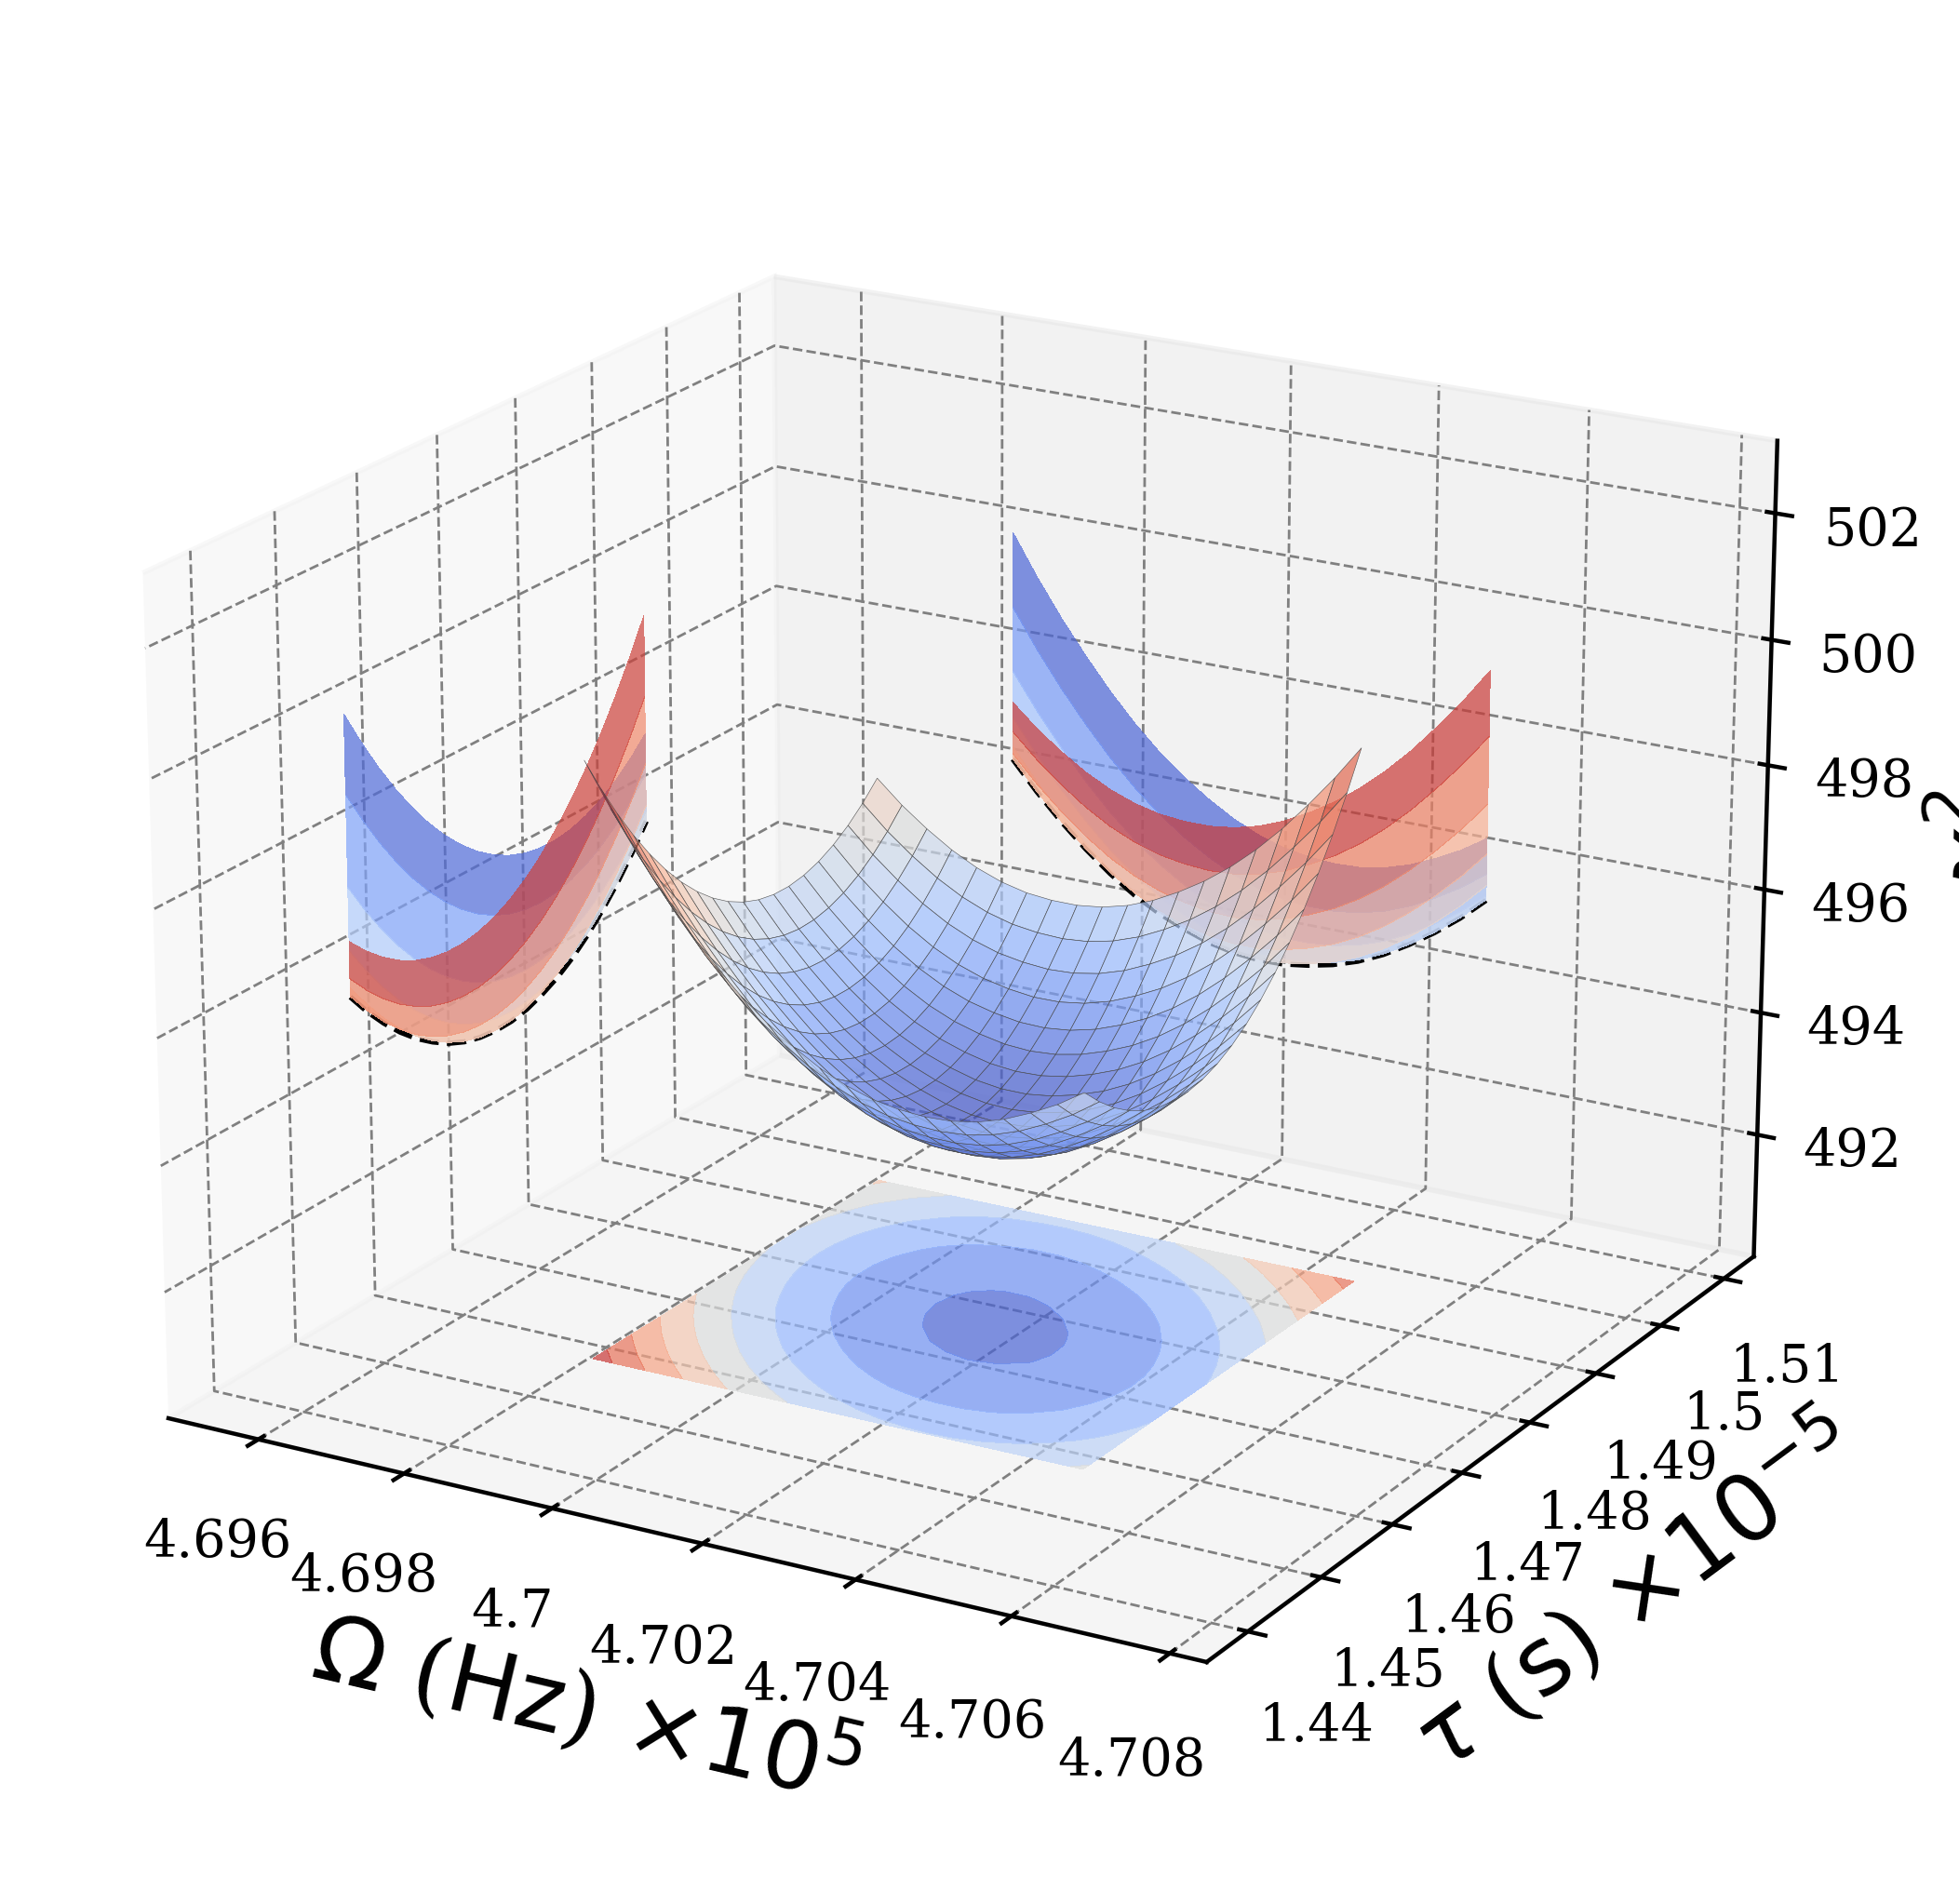

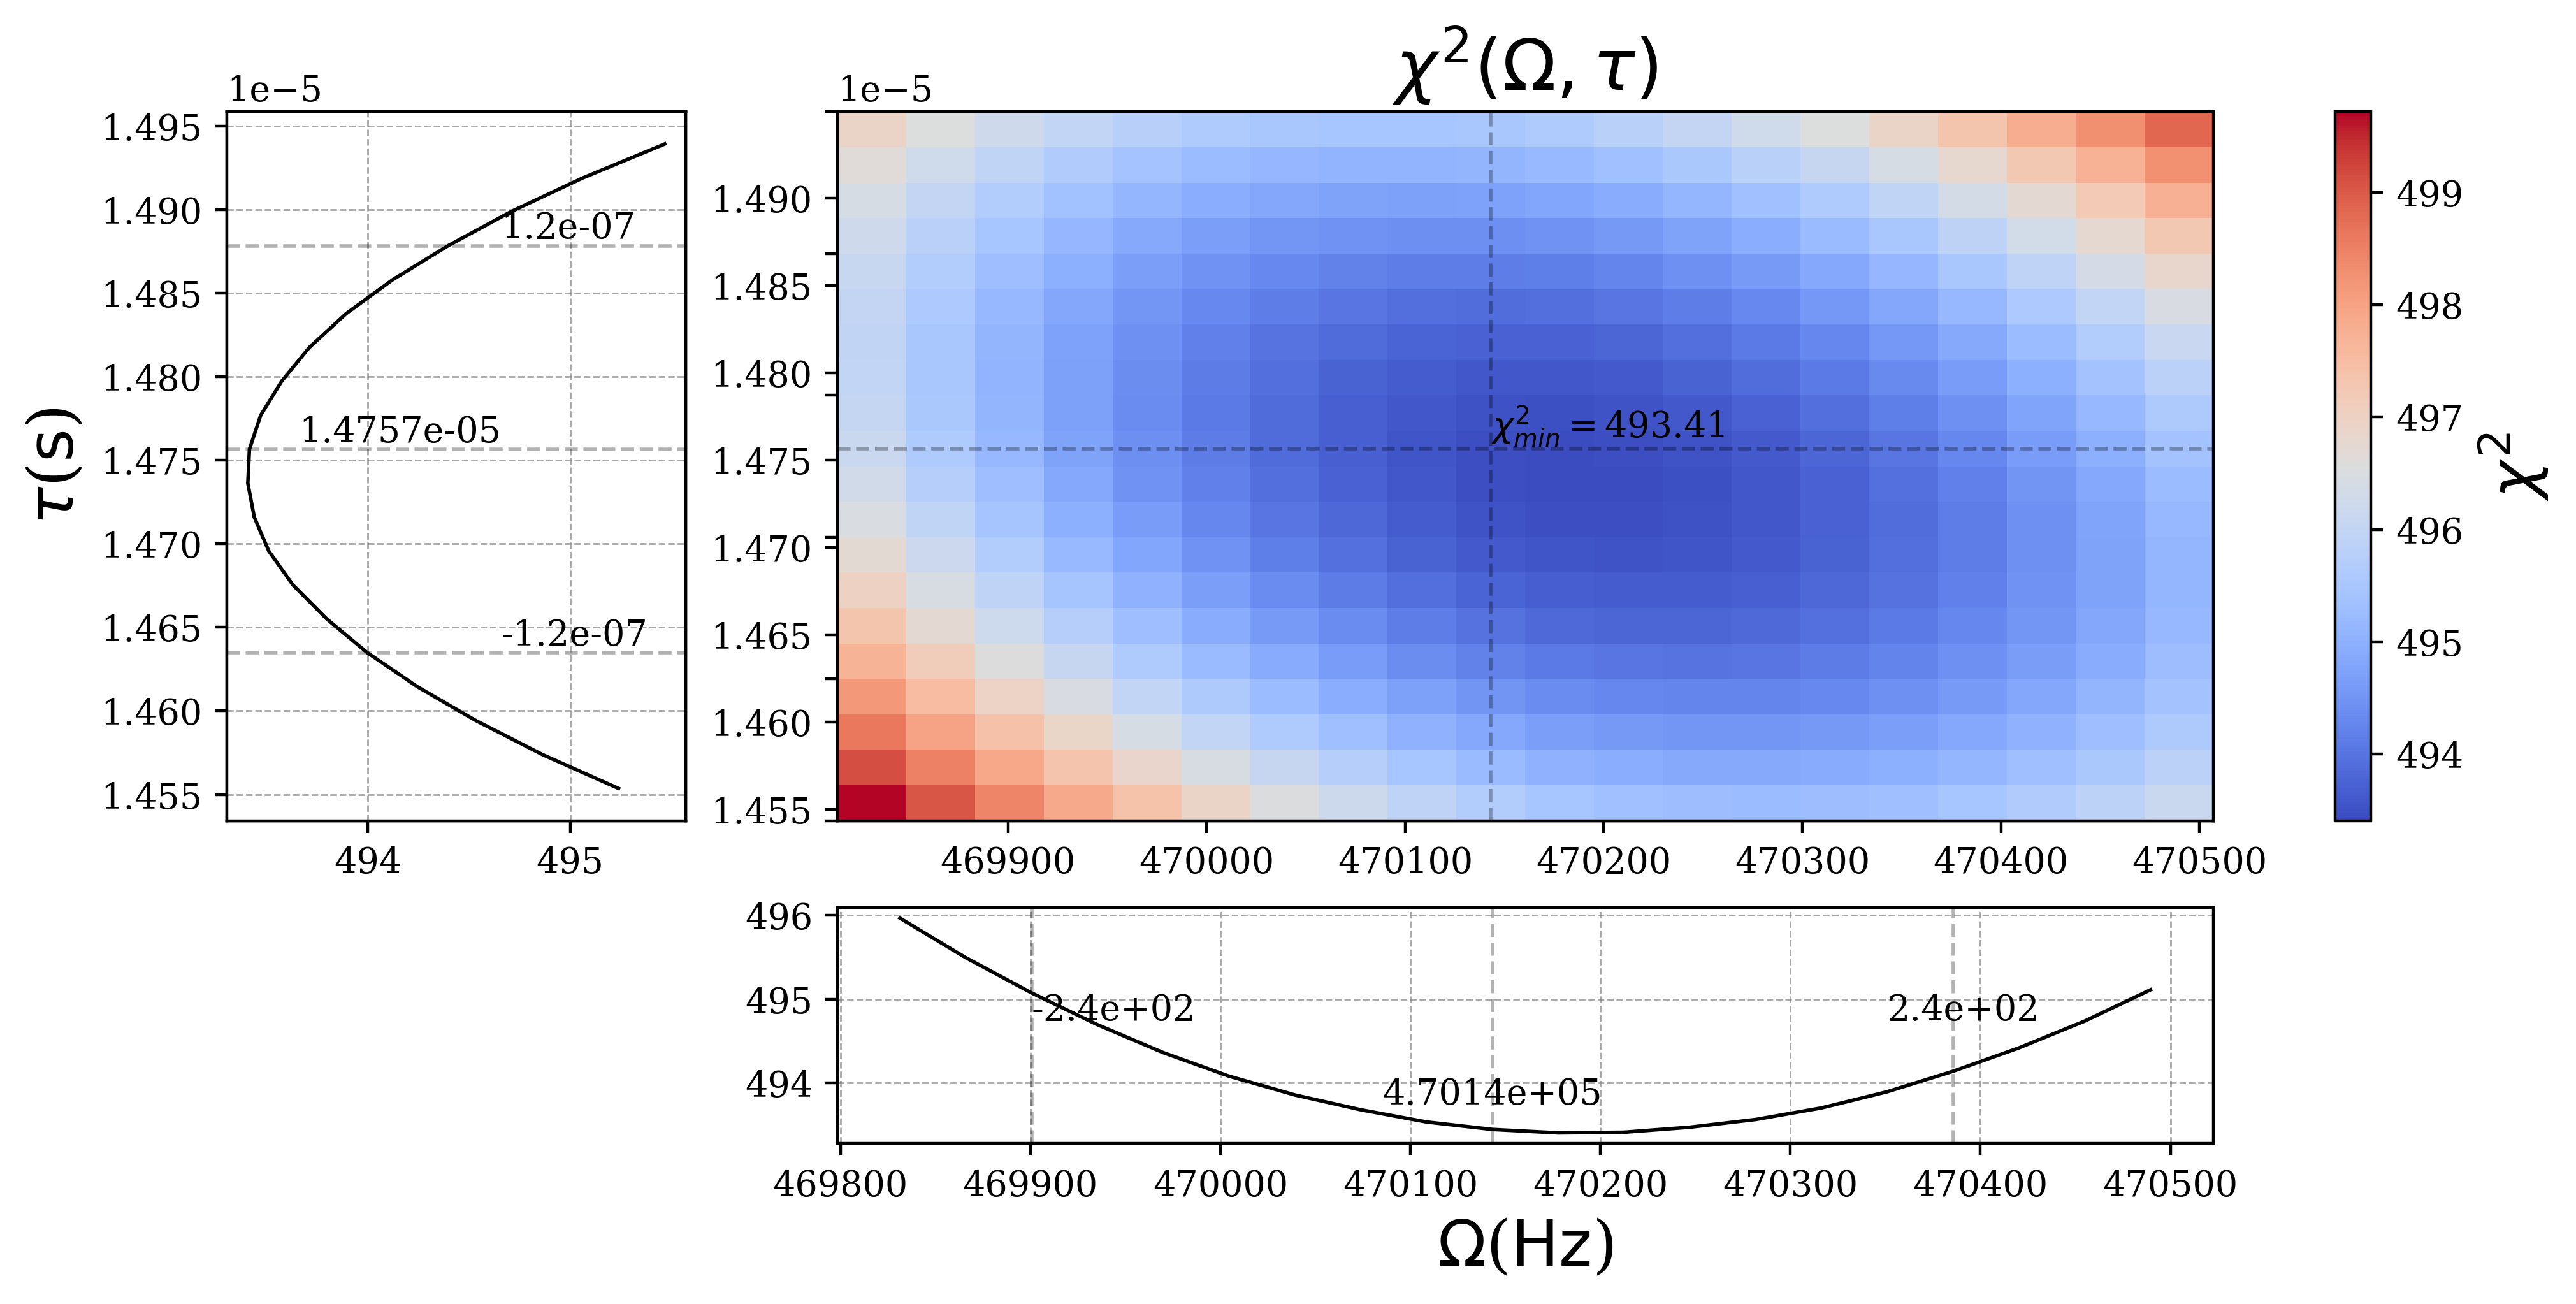

In [74]:
grafico_chi('O', "Omega", "tau", r"($\mathrm{Hz}$)", r"($\mathrm{s}$)")

## 2. V e Tau

Creazione griglia chi

/tmp/ipykernel_10893/3846358886.py:98: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  colore = ax1.pcolormesh(X, Y, Z, shading='auto', cmap='coolwarm')


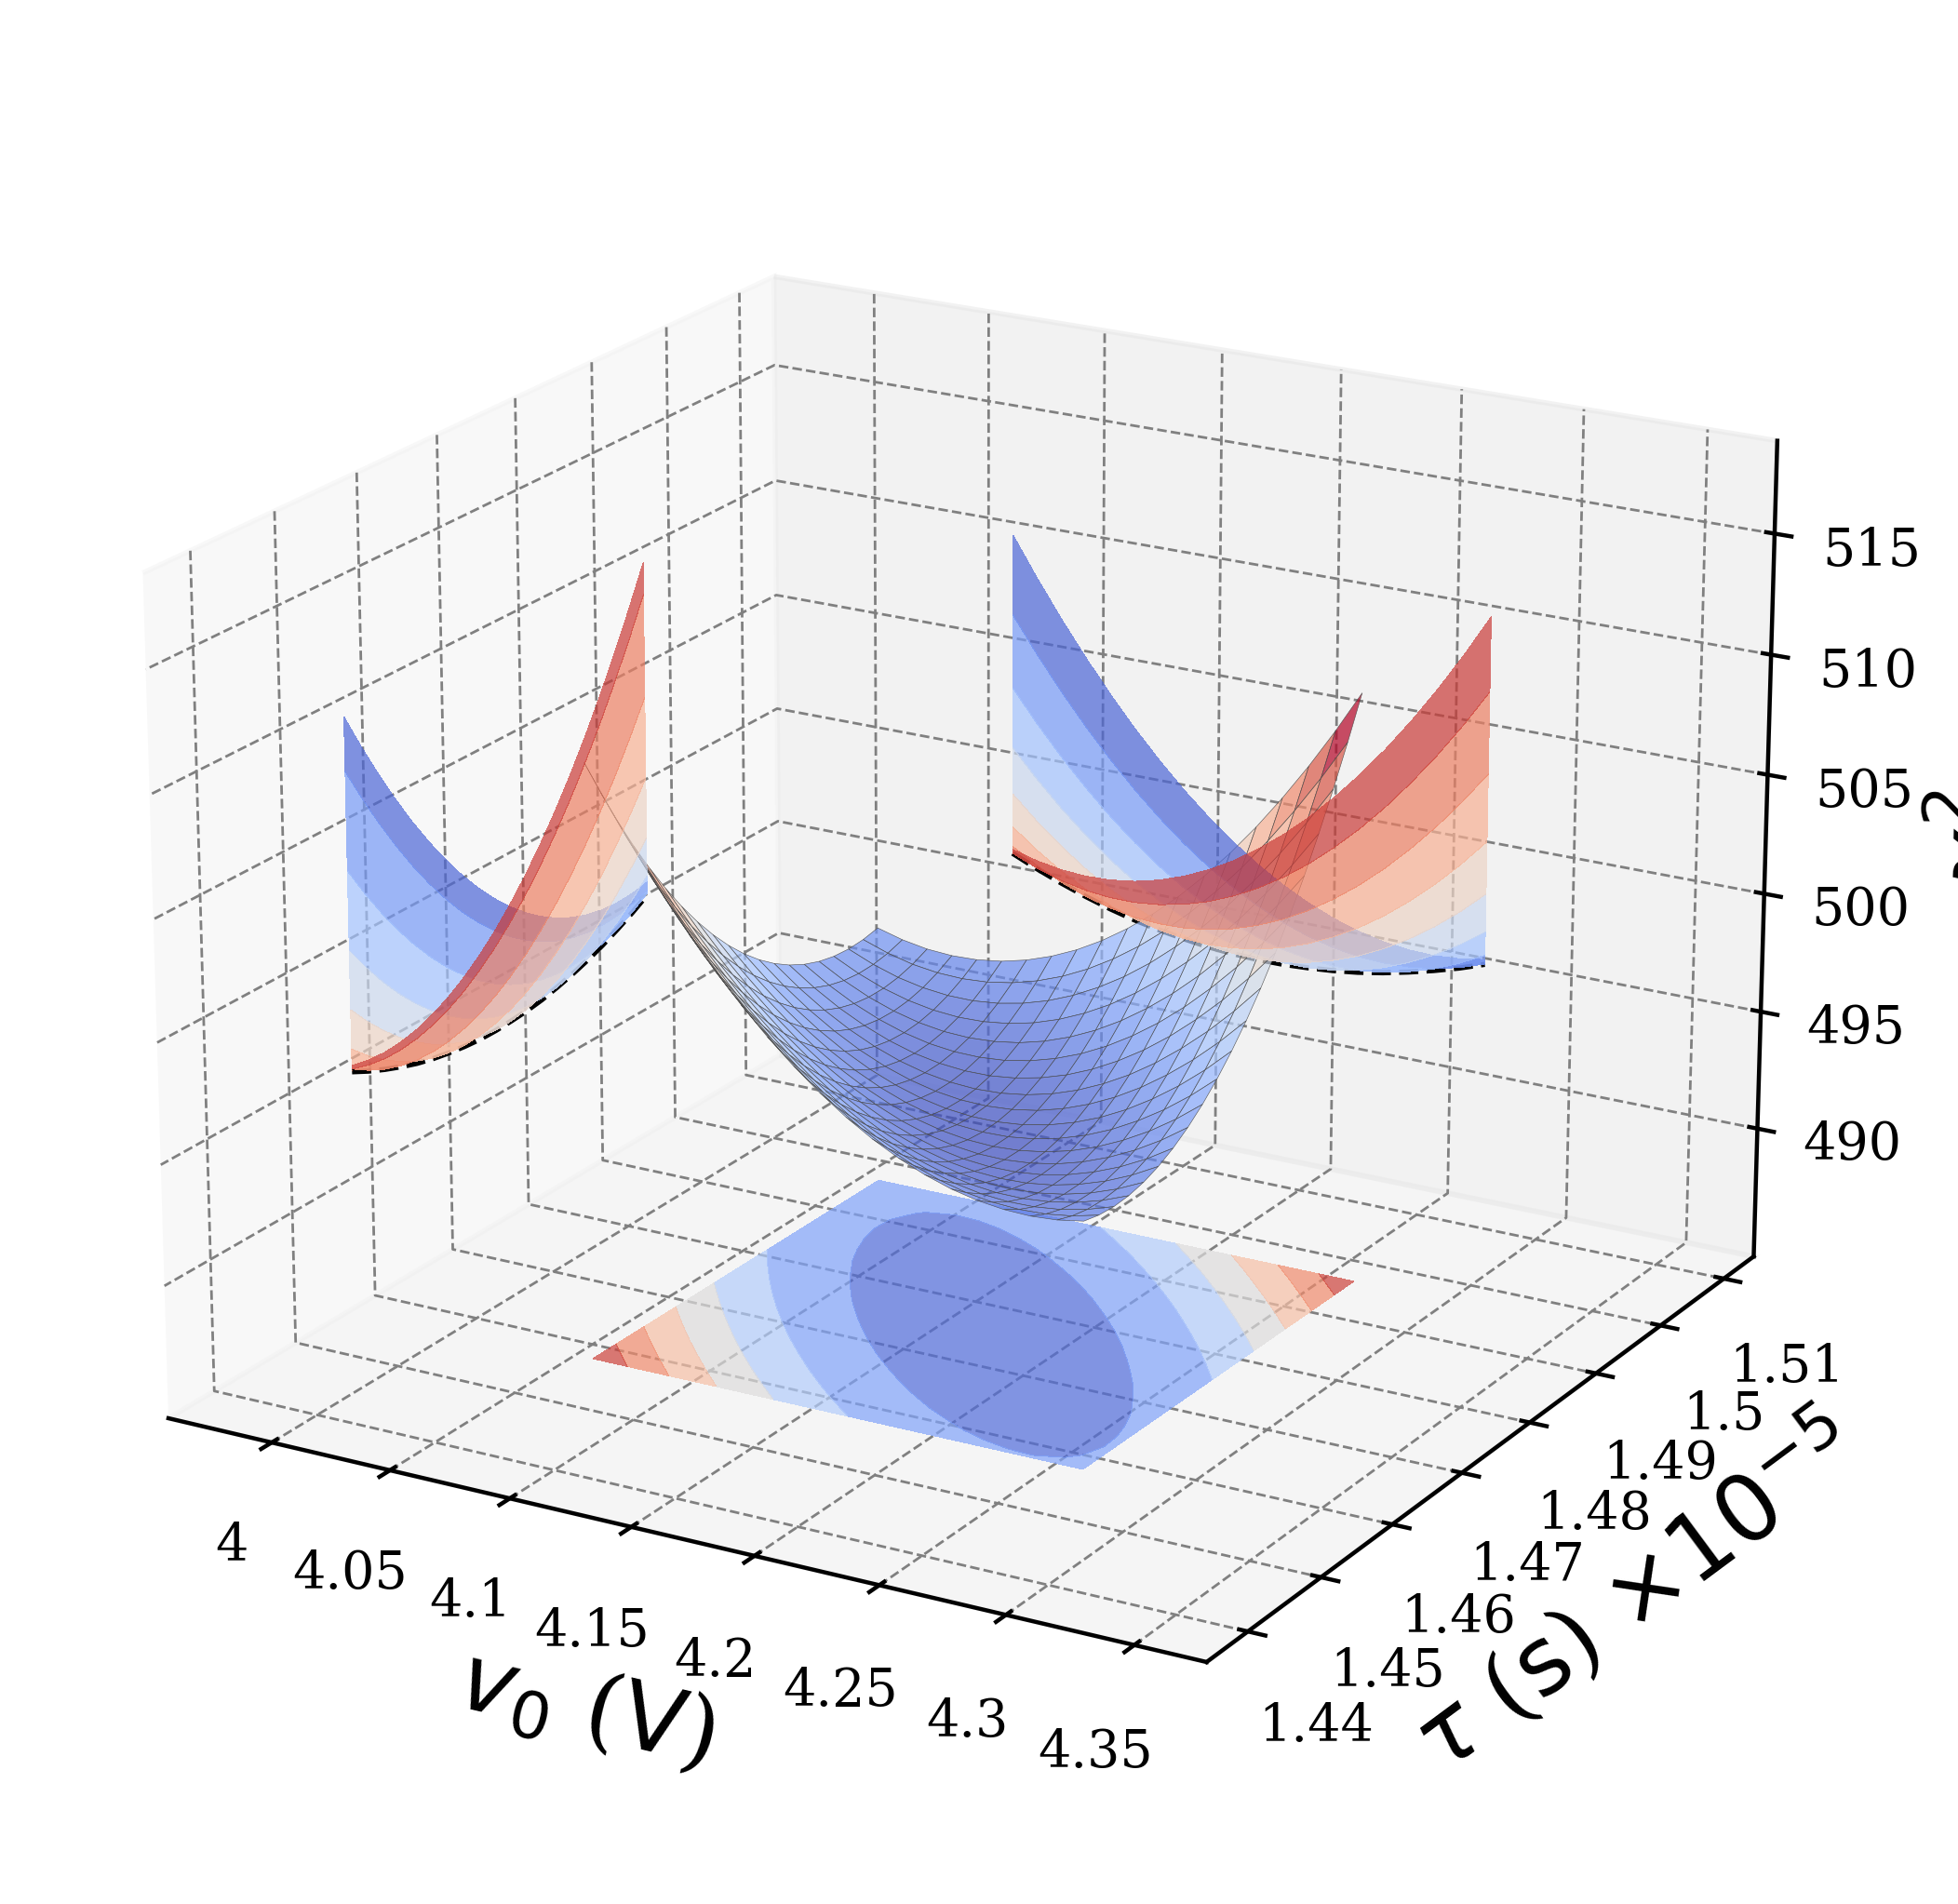

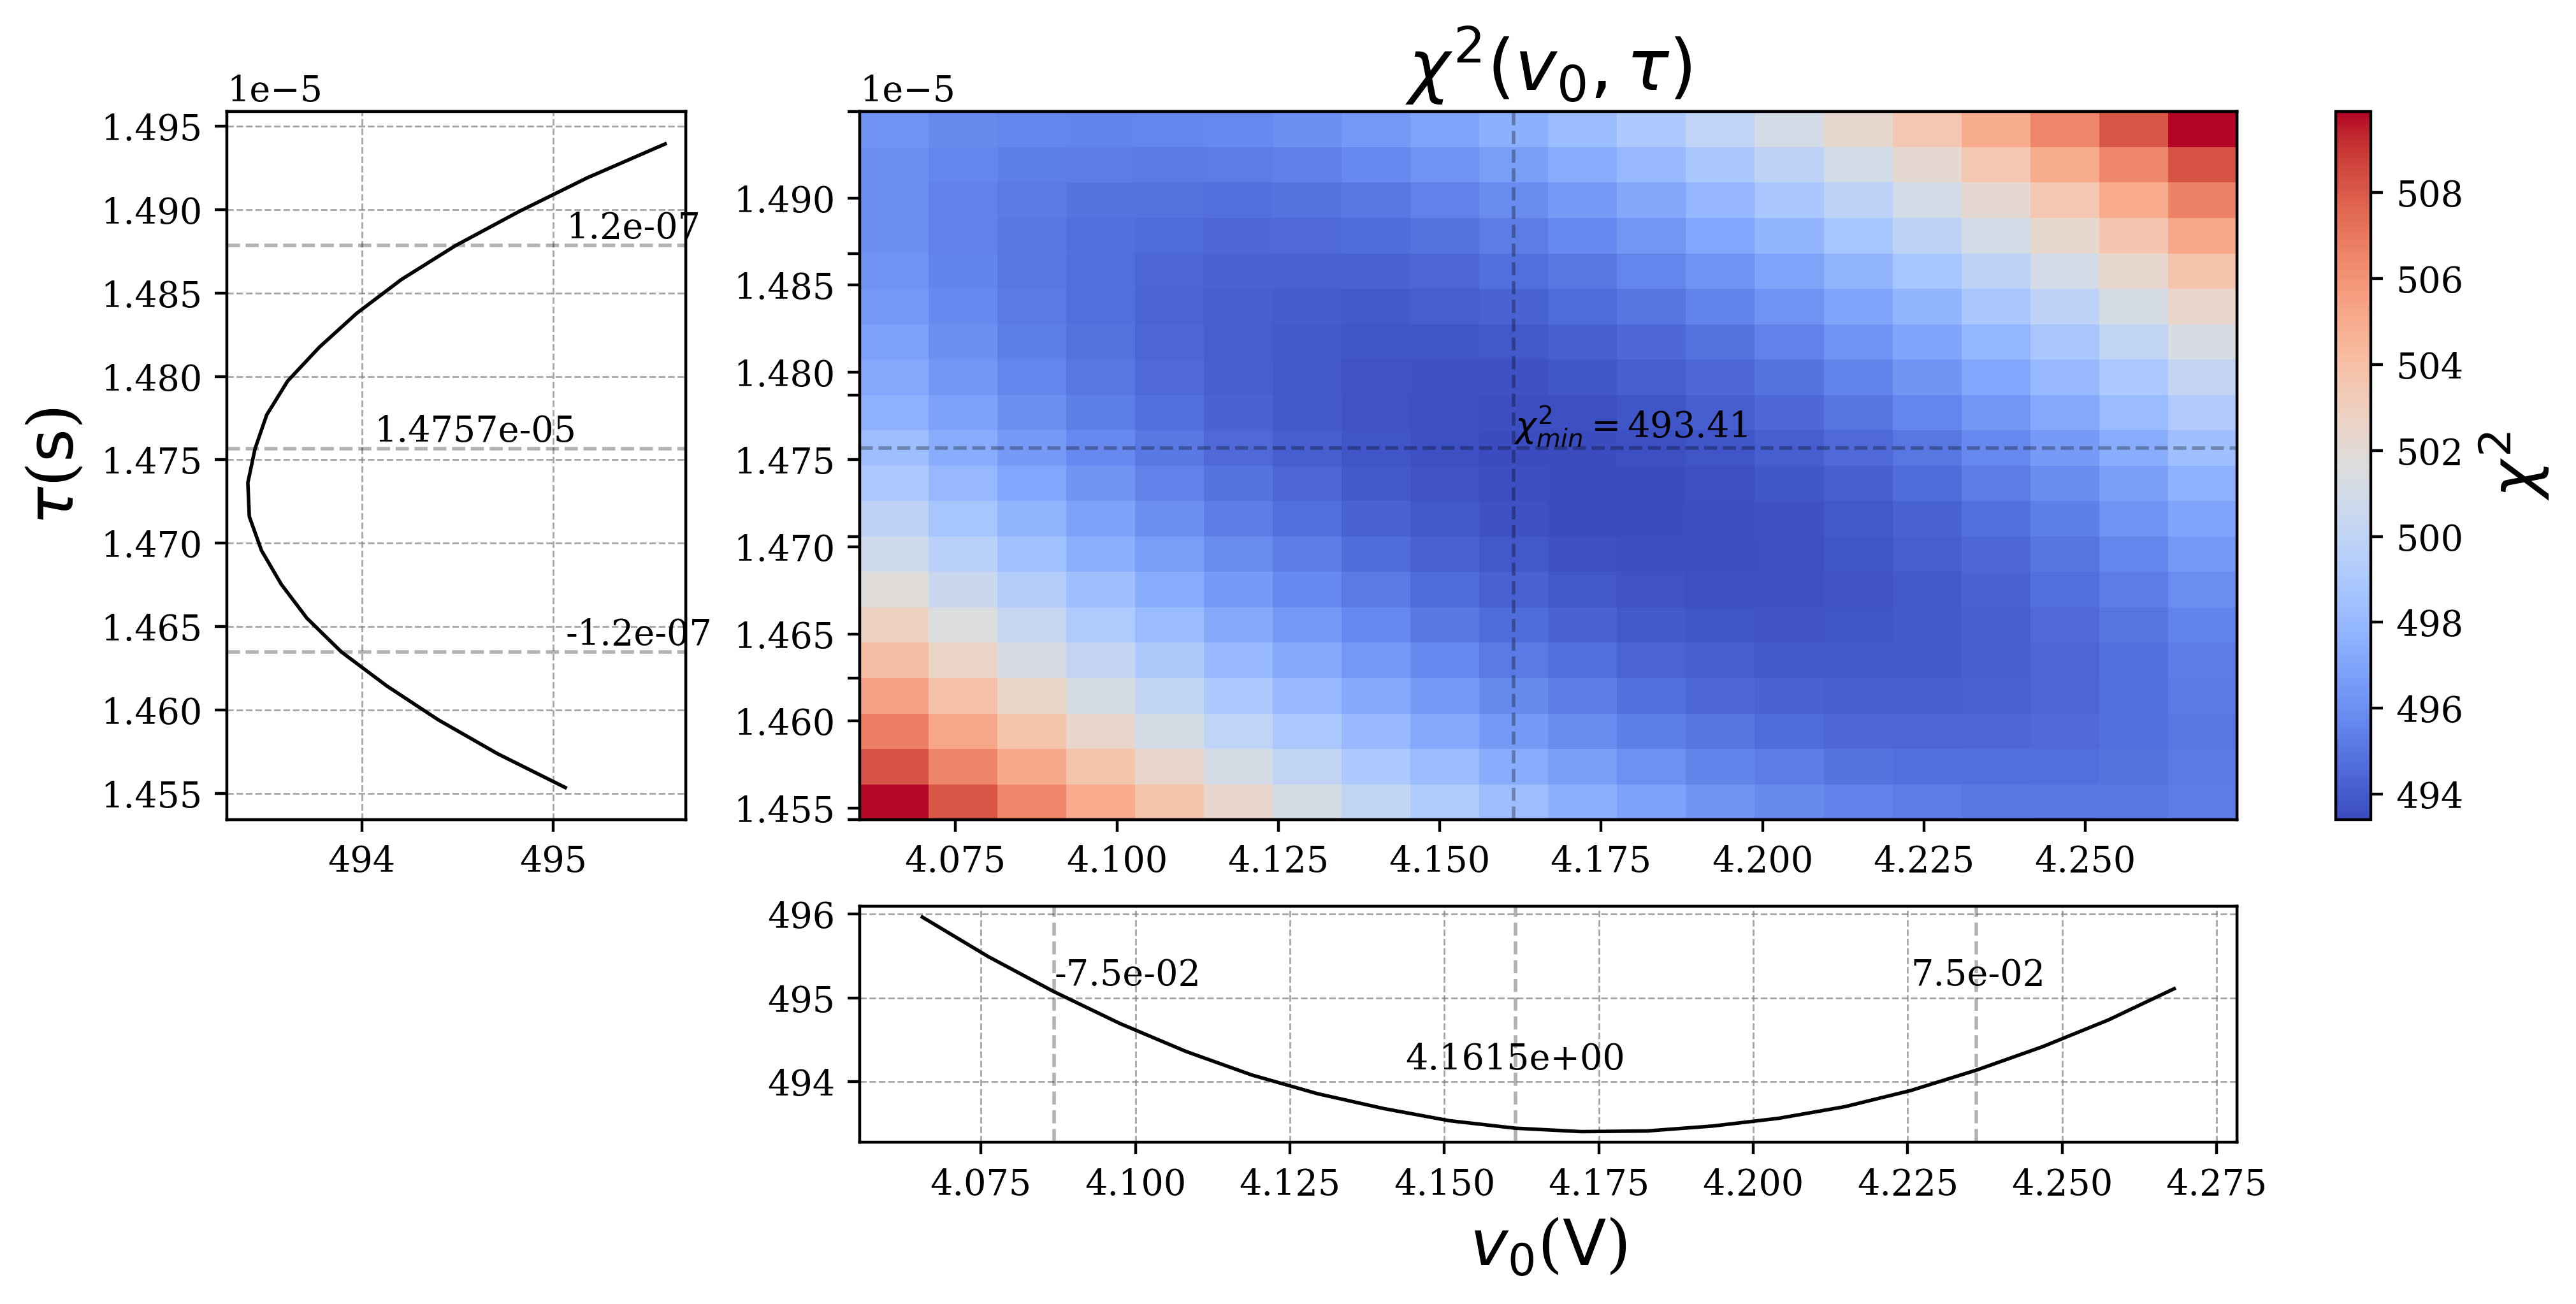

In [75]:
grafico_chi('V', "v_0", "tau", r"($\mathrm{V}$)", r"($\mathrm{s}$)")

# Esportazione Dati

Semplicemente per risparmiare tempo dato che il calcolo di questi dati è molto lenta.

In [60]:
let.esporta_pickle(mappa, filename="chi.pkl")